In [1]:
pip install shap


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Import 

In [3]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

## Import Data

In [4]:
df = pd.read_csv("../data/processed/preprocessed_data.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Split Feature and target

In [5]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Load best Model

In [6]:
best_model = joblib.load("../models/logistic_regression_tuned.pkl")

## View Pipeline

In [7]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

## Seperate preprocessor and classifier

In [8]:
preprocessor = best_model.named_steps["preprocessor"]

classifier = best_model.named_steps["classifier"]

## Transform the test data 

In [9]:
X_test_processed = preprocessor.transform(X_test)

## Get Feature names

In [10]:
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges', ...,
       'cat__TotalCharges_999.45', 'cat__TotalCharges_999.8',
       'cat__TotalCharges_999.9'], shape=(5320,), dtype=object)

## Create SHAP explainer

In [11]:
explainer = shap.LinearExplainer(
    classifier,
    X_test_processed
)

Background dataset has 1409 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1409 when initializing the masker.


## Calculate SHAP Value

In [12]:
shap_values = explainer(X_test_processed)

## SHAP summary Plot

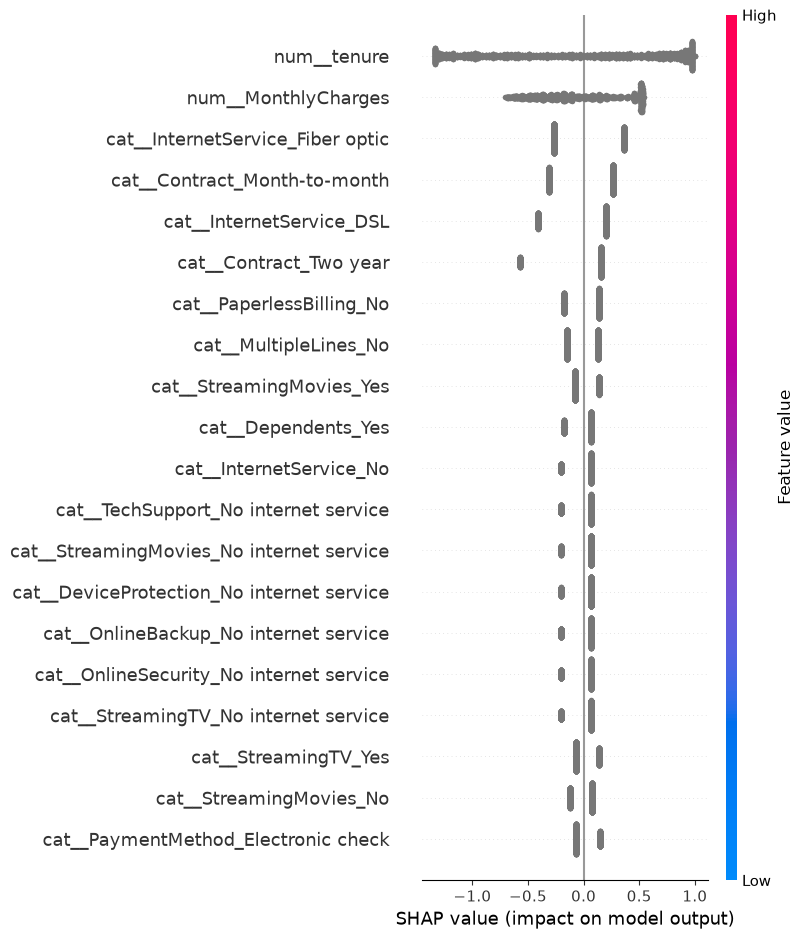

In [13]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

In [14]:
probabilities = best_model.predict_proba(X_test)[:, 1]

In [15]:
highest_risk = np.argmax(probabilities)

highest_risk

np.int64(1090)

In [16]:
print(
    "Predicted Churn Probability:",
    probabilities[highest_risk]
)

Predicted Churn Probability: 0.8710260591540526


## Feature Importance bar plot

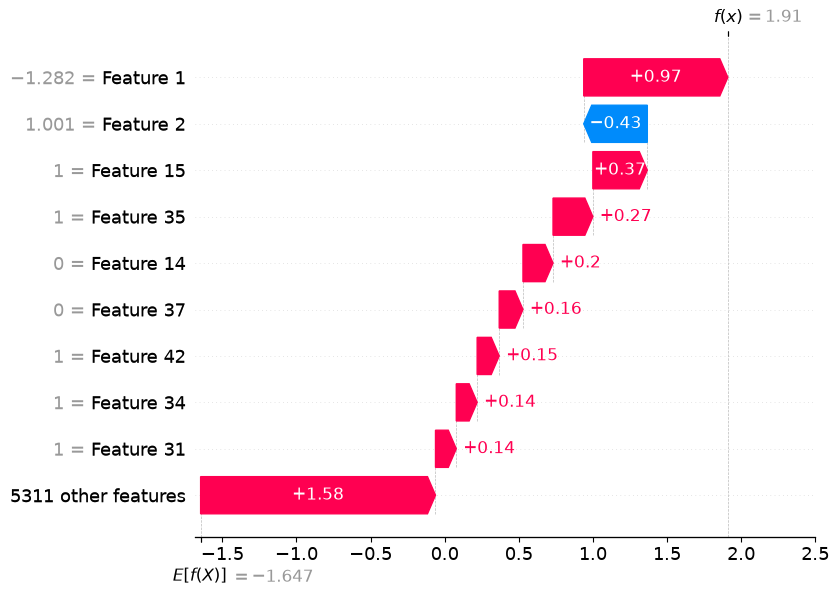

In [17]:
shap.plots.waterfall(
    shap_values[highest_risk]
)

## Feature Importance table 

In [18]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": np.abs(shap_values.values).mean(axis=0)
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
1,num__tenure,0.708976
2,num__MonthlyCharges,0.332572
15,cat__InternetService_Fiber optic,0.310146
35,cat__Contract_Month-to-month,0.289783
14,cat__InternetService_DSL,0.274587
37,cat__Contract_Two year,0.257512
38,cat__PaperlessBilling_No,0.152097
11,cat__MultipleLines_No,0.139566
34,cat__StreamingMovies_Yes,0.102336
8,cat__Dependents_Yes,0.101181


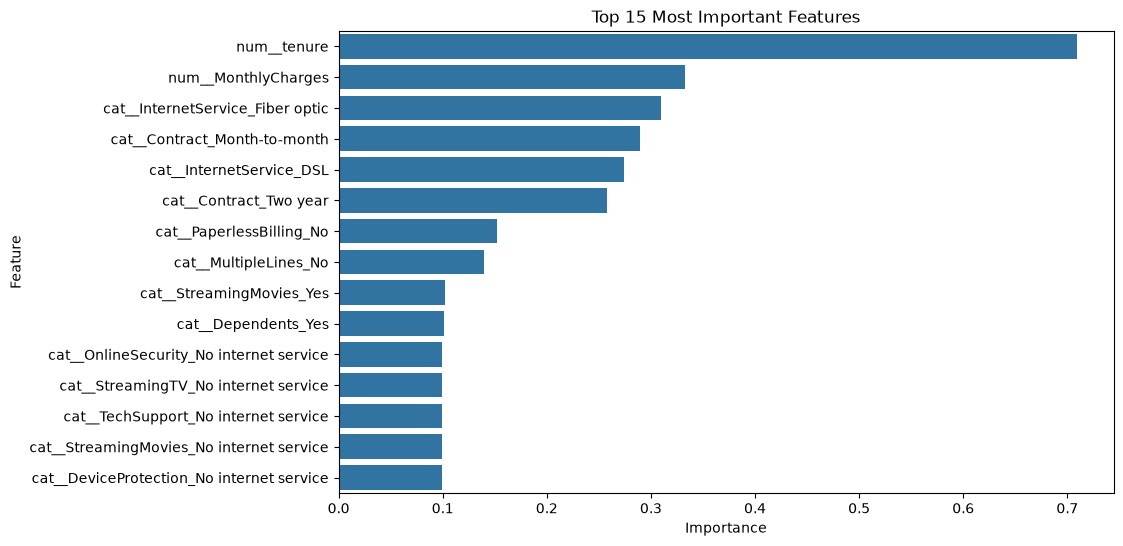

In [19]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features")

plt.show()

## Save Importance Table 

In [24]:
importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

## Model Explainability

SHAP analysis was used to understand the drivers of customer churn.

The model identified the most influential features affecting churn predictions, enabling transparent decision-making and actionable business insights.

Key findings include:

- Contract type significantly impacts churn probability.
- Customers with shorter tenure are more likely to churn.
- Higher monthly charges increase churn risk.
- Customers lacking Online Security and Tech Support show higher churn tendencies.

These insights can help businesses prioritize customer retention strategies and improve long-term customer value.